<a href="https://colab.research.google.com/github/siravitgonarm/customer-booking-prediction/blob/main/customer_booking_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore")

filename = list(uploaded.keys())[0]

if filename.endswith(".csv"):
    df = pd.read_csv(filename, encoding="latin-1")
else:
    df = pd.read_excel(filename)

print(f"Data loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Saving customer_booking.csv to customer_booking (1).csv
Data loaded: 50,000 rows × 14 columns


,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0


In [3]:
print(df.dtypes)
print(df.describe())
print(df["booking_complete"].value_counts())
print(f"Booking Rate: {df['booking_complete'].mean()*100:.2f}%")
print(df.isnull().sum())

num_passengers             int64
sales_channel             object
trip_type                 object
purchase_lead              int64
length_of_stay             int64
flight_hour                int64
flight_day                object
route                     object
booking_origin            object
wants_extra_baggage        int64
wants_preferred_seat       int64
wants_in_flight_meals      int64
flight_duration          float64
booking_complete           int64
dtype: object
       num_passengers  purchase_lead  length_of_stay  flight_hour  \
count    50000.000000   50000.000000     50000.00000  50000.00000   
mean         1.591240      84.940480        23.04456      9.06634   
std          1.020165      90.451378        33.88767      5.41266   
min          1.000000       0.000000         0.00000      0.00000   
25%          1.000000      21.000000         5.00000      5.00000   
50%          1.000000      51.000000        17.00000      9.00000   
75%          2.000000     115.000000     

In [4]:
df["is_weekend"] = df["flight_day"].isin(["Sat", "Sun"]).astype(int)
df["is_offpeak_hour"] = ((df["flight_hour"] < 6) | (df["flight_hour"] >= 22)).astype(int)
df["total_addons"] = df["wants_extra_baggage"] + df["wants_preferred_seat"] + df["wants_in_flight_meals"]
df["is_last_minute"] = (df["purchase_lead"] <= 7).astype(int)

day_map = {"Mon":0,"Tue":1,"Wed":2,"Thu":3,"Fri":4,"Sat":5,"Sun":6}
df["flight_day_num"] = df["flight_day"].map(day_map)

le = LabelEncoder()
df["sales_channel_enc"]  = le.fit_transform(df["sales_channel"])
df["trip_type_enc"]      = le.fit_transform(df["trip_type"])
df["route_enc"]          = le.fit_transform(df["route"])
df["booking_origin_enc"] = le.fit_transform(df["booking_origin"])

print("Feature engineering done")
df.head()

Feature engineering done


,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,...,booking_complete,is_weekend,is_offpeak_hour,total_addons,is_last_minute,flight_day_num,sales_channel_enc,trip_type_enc,route_enc,booking_origin_enc
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,...,0,1,0,1,0,5,0,2,0,61
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,...,0,1,1,0,0,5,0,2,0,61
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,...,0,0,0,2,0,2,0,2,0,36
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,...,0,1,1,1,0,5,0,2,0,61
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,...,0,0,0,2,0,2,0,2,0,36


In [5]:
FEATURES = [
    "num_passengers", "purchase_lead", "length_of_stay", "flight_hour",
    "flight_duration", "wants_extra_baggage", "wants_preferred_seat",
    "wants_in_flight_meals", "sales_channel_enc", "trip_type_enc",
    "route_enc", "booking_origin_enc",
    "is_weekend", "is_offpeak_hour", "total_addons", "is_last_minute",
    "flight_day_num",
]
X = df[FEATURES]
y = df["booking_complete"]
print(f"X shape: {X.shape}")

X shape: (50000, 17)


In [6]:
rf = RandomForestClassifier(
    n_estimators=200, max_depth=10, min_samples_leaf=20,
    class_weight="balanced", random_state=42, n_jobs=-1,
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_acc = cross_val_score(rf, X, y, cv=cv, scoring="accuracy")
cv_roc = cross_val_score(rf, X, y, cv=cv, scoring="roc_auc")
cv_f1  = cross_val_score(rf, X, y, cv=cv, scoring="f1")

print(f"Accuracy : {cv_acc.mean():.4f} ± {cv_acc.std():.4f}")
print(f"ROC-AUC  : {cv_roc.mean():.4f} ± {cv_roc.std():.4f}")
print(f"F1-Score : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")

rf.fit(X, y)

Accuracy : 0.6980 ± 0.0032
ROC-AUC  : 0.7654 ± 0.0040
F1-Score : 0.4149 ± 0.0022


RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=20, n_estimators=200, n_jobs=-1,
                       random_state=42)

In [7]:
label_map = {
    "booking_origin_enc":"Booking Origin", "route_enc":"Route",
    "length_of_stay":"Length of Stay", "flight_duration":"Flight Duration",
    "purchase_lead":"Purchase Lead Time", "total_addons":"Total Add-ons",
    "flight_hour":"Flight Hour", "wants_extra_baggage":"Extra Baggage",
    "sales_channel_enc":"Sales Channel", "flight_day_num":"Day of Week",
    "num_passengers":"Num Passengers", "wants_preferred_seat":"Preferred Seat",
    "wants_in_flight_meals":"In-flight Meals", "trip_type_enc":"Trip Type",
    "is_weekend":"Is Weekend", "is_offpeak_hour":"Off-peak Hour",
    "is_last_minute":"Last Minute",
}

fi = pd.DataFrame({"feature": FEATURES, "importance": rf.feature_importances_})
fi = fi.sort_values("importance", ascending=False).reset_index(drop=True)
fi["label"] = fi["feature"].map(label_map)
fi.head(10)

,feature,importance,label
0,booking_origin_enc,0.421824,Booking Origin
1,route_enc,0.126488,Route
2,length_of_stay,0.110960,Length of Stay
3,flight_duration,0.093862,Flight Duration
4,purchase_lead,0.061258,Purchase Lead Time
5,total_addons,0.036077,Total Add-ons
6,flight_hour,0.033656,Flight Hour
7,wants_extra_baggage,0.027396,Extra Baggage
8,sales_channel_enc,0.020904,Sales Channel
9,flight_day_num,0.019846,Day of Week


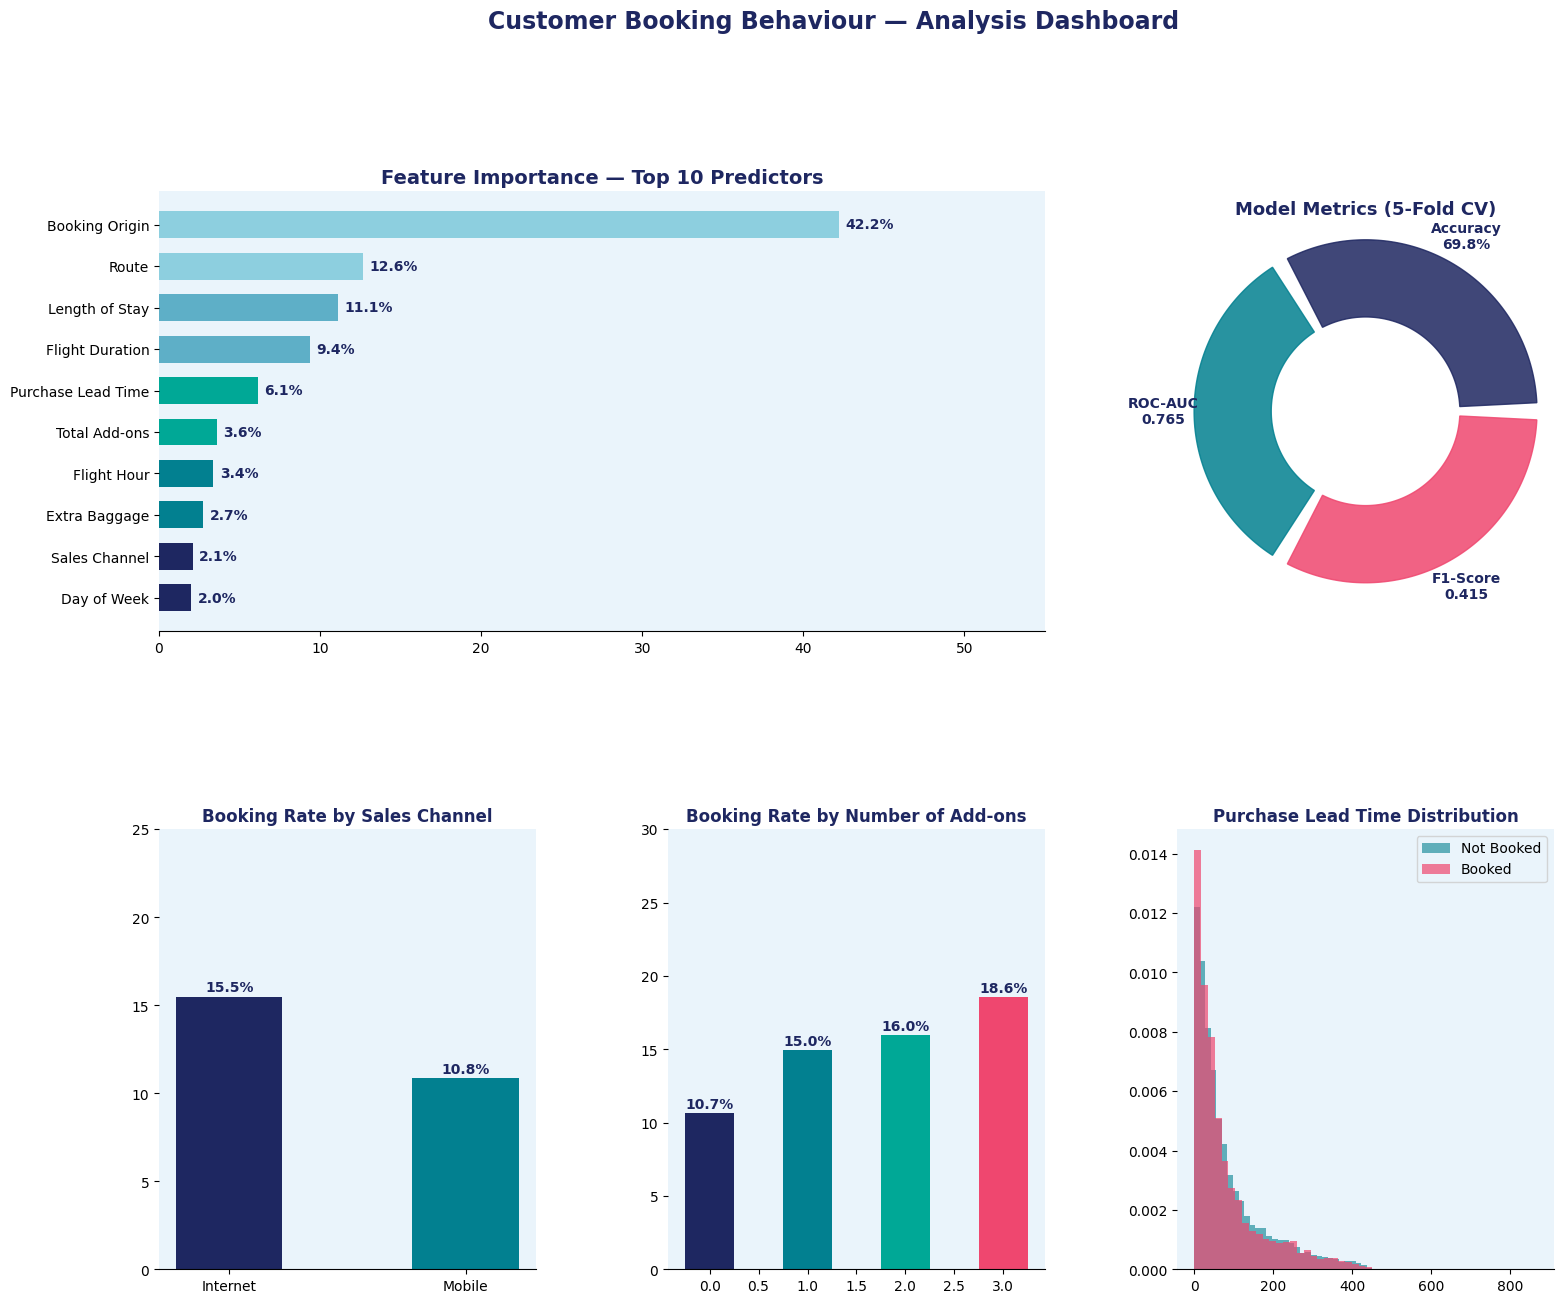

In [8]:
NAVY, TEAL, TEAL2, CORAL = "#1E2761","#028090","#00A896","#EF476F"
LGRAY, WHITE, BGLIGHT = "#CBD5E1","#FFFFFF","#EAF4FB"

plt.rcParams.update({
    "figure.facecolor": WHITE, "axes.facecolor": BGLIGHT,
    "axes.spines.top": False, "axes.spines.right": False, "axes.spines.left": False,
    "grid.color": LGRAY, "grid.alpha": 0.5,
})

fig = plt.figure(figsize=(18, 14))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# Feature importance
ax1 = fig.add_subplot(gs[0, :2])
fi_top = fi.head(10)
colors_bar = [NAVY,NAVY,TEAL,TEAL,TEAL2,TEAL2,"#5EAFC7","#5EAFC7","#8DCFDF","#8DCFDF"]
bars = ax1.barh(fi_top["label"][::-1], fi_top["importance"][::-1]*100, color=colors_bar, height=0.65)
for bar, val in zip(bars, fi_top["importance"][::-1]*100):
    ax1.text(bar.get_width()+0.4, bar.get_y()+bar.get_height()/2, f"{val:.1f}%", va="center", fontweight="bold", color=NAVY)
ax1.set_title("Feature Importance — Top 10 Predictors", fontsize=14, fontweight="bold", color=NAVY)
ax1.set_xlim(0, 55)

# CV Metrics donut
ax2 = fig.add_subplot(gs[0, 2])
metrics = {f"Accuracy\n{cv_acc.mean()*100:.1f}%": cv_acc.mean(),
           f"ROC-AUC\n{cv_roc.mean():.3f}": cv_roc.mean(),
           f"F1-Score\n{cv_f1.mean():.3f}": cv_f1.mean()}
mc = [NAVY, TEAL, CORAL]
angles = np.linspace(0, 2*np.pi, len(metrics)+1)
for i, ((lbl,val), col) in enumerate(zip(metrics.items(), mc)):
    theta = np.linspace(0.05+angles[i], angles[i+1]-0.05, 100)
    x_out, y_out = np.cos(theta), np.sin(theta)
    x_in, y_in = 0.55*np.cos(theta[::-1]), 0.55*np.sin(theta[::-1])
    ax2.fill(np.concatenate([x_out,x_in]), np.concatenate([y_out,y_in]), color=col, alpha=0.85)
    mid = (angles[i]+angles[i+1])/2
    ax2.text(1.18*np.cos(mid), 1.18*np.sin(mid), lbl, ha="center", va="center", fontweight="bold", color=NAVY)
ax2.set_aspect("equal"); ax2.axis("off")
ax2.set_title("Model Metrics (5-Fold CV)", fontsize=13, fontweight="bold", color=NAVY)

# Booking rate by sales channel
ax3 = fig.add_subplot(gs[1, 0])
ch_rate = df.groupby("sales_channel")["booking_complete"].mean()*100
brs3 = ax3.bar(ch_rate.index, ch_rate.values, color=[NAVY,TEAL], width=0.45)
for b in brs3:
    ax3.text(b.get_x()+b.get_width()/2, b.get_height()+0.3, f"{b.get_height():.1f}%", ha="center", fontweight="bold", color=NAVY)
ax3.set_title("Booking Rate by Sales Channel", fontsize=12, fontweight="bold", color=NAVY)
ax3.set_ylim(0,25)

# Booking rate by add-ons
ax4 = fig.add_subplot(gs[1, 1])
addon_rate = df.groupby("total_addons")["booking_complete"].mean()*100
brs4 = ax4.bar(addon_rate.index, addon_rate.values, color=[NAVY,TEAL,TEAL2,CORAL][:len(addon_rate)], width=0.5)
for b in brs4:
    ax4.text(b.get_x()+b.get_width()/2, b.get_height()+0.3, f"{b.get_height():.1f}%", ha="center", fontweight="bold", color=NAVY)
ax4.set_title("Booking Rate by Number of Add-ons", fontsize=12, fontweight="bold", color=NAVY)
ax4.set_ylim(0,30)

# Purchase lead distribution
ax5 = fig.add_subplot(gs[1, 2])
ax5.hist(df[df["booking_complete"]==0]["purchase_lead"], bins=50, color=TEAL, alpha=0.6, label="Not Booked", density=True)
ax5.hist(df[df["booking_complete"]==1]["purchase_lead"], bins=50, color=CORAL, alpha=0.7, label="Booked", density=True)
ax5.set_title("Purchase Lead Time Distribution", fontsize=12, fontweight="bold", color=NAVY)
ax5.legend()

fig.suptitle("Customer Booking Behaviour — Analysis Dashboard", fontsize=17, fontweight="bold", color=NAVY, y=1.01)
plt.savefig("customer_booking_dashboard.png", dpi=150, bbox_inches="tight", facecolor=WHITE)
plt.show()

In [9]:
files.download("customer_booking_dashboard.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>